# COVID-19 Forecasting

This notebook prepares a state-level daily dataset from the Johns Hopkins CSSE US time-series files, reviews simple baselines, and runs a first GRU benchmark.

Supporting scripts:
- `scripts/prepare_dataset.py`
- `scripts/process_pipeline.py`


In [1]:
from pathlib import Path
import sys
import warnings

from IPython.display import display

missing_packages = []

try:
    import numpy as np
except ModuleNotFoundError:
    np = None
    missing_packages.append("numpy")

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None
    missing_packages.append("pandas")

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    missing_packages.append("matplotlib")

if missing_packages:
    missing_list = ", ".join(missing_packages)
    raise ModuleNotFoundError(
        "Install the dependencies from requirements.txt before running this notebook. "
        f"Missing packages: {missing_list}"
    )

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)


/Users/magicalfeyfenny/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/8c/qf6_lkqs7mv2_xtj6yqn8znc0000gn/T/matplotlib-xah4irjx because there was an issue with the default path (/Users/magicalfeyfenny/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.prepare_dataset import (
    EXPECTED_RAW_FILES,
    find_raw_data_dir,
    list_missing_raw_files,
    prepare_dataset,
    write_state_daily_csv,
)
from scripts.process_pipeline import (
    DEFAULT_BASELINE_SPECS,
    DEFAULT_EVAL_DAYS,
    DEFAULT_FEATURE_COLUMNS,
    DEFAULT_FORECAST_HORIZON,
    DEFAULT_LOOKBACK_DAYS,
    DEFAULT_SEQUENCE_BASELINE_SPECS,
    build_sequence_baseline_frame,
    compare_baselines,
    compare_baselines_by_state,
    run_processing_pipeline,
    split_sequence_dataset_by_date,
    summarize_best_baseline_by_state,
)

RAW_DATA_DIR = find_raw_data_dir(PROJECT_ROOT)
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

for directory in [PROJECT_ROOT / "data" / "raw", PROCESSED_DATA_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")
print(f"PROCESSED_DATA_DIR: {PROCESSED_DATA_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")


PROJECT_ROOT: /Users/magicalfeyfenny/GitHub/COVID-19
RAW_DATA_DIR: /Users/magicalfeyfenny/GitHub/COVID-19/csse_covid_19_data/csse_covid_19_time_series
PROCESSED_DATA_DIR: /Users/magicalfeyfenny/GitHub/COVID-19/data/processed
FIGURES_DIR: /Users/magicalfeyfenny/GitHub/COVID-19/figures


## Data Sources

This notebook checks these locations in order:
- `data/raw/`
- `csse_covid_19_data/csse_covid_19_time_series/`

Expected raw files:
- `time_series_covid19_confirmed_US.csv`
- `time_series_covid19_deaths_US.csv`


In [3]:
FEATURE_COLUMNS = DEFAULT_FEATURE_COLUMNS.copy()
BASELINE_SPECS = DEFAULT_BASELINE_SPECS.copy()
SEQUENCE_BASELINE_SPECS = DEFAULT_SEQUENCE_BASELINE_SPECS.copy()
EVAL_DAYS = DEFAULT_EVAL_DAYS
LOOKBACK_DAYS = DEFAULT_LOOKBACK_DAYS
FORECAST_HORIZON = DEFAULT_FORECAST_HORIZON


In [4]:
def plot_baseline_comparison(frame, state_name, prediction_specs, actual_column="new_cases", start_date=None):
    state_frame = frame[frame["state"] == state_name].copy()

    if start_date is not None:
        state_frame = state_frame[state_frame["date"] >= pd.to_datetime(start_date)]

    if state_frame.empty:
        print(f"No data found for {state_name}.")
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(state_frame["date"], state_frame[actual_column], label="Actual", linewidth=2.0, color="black")

    for label, prediction_column in prediction_specs:
        if prediction_column in state_frame.columns:
            ax.plot(state_frame["date"], state_frame[prediction_column], label=label, linewidth=1.5, alpha=0.9)

    ax.set_title(f"{state_name} - baseline comparison on the eval window")
    ax.set_xlabel("Date")
    ax.set_ylabel(actual_column)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    backend_name = plt.get_backend().lower()
    if "agg" in backend_name:
        plt.close(fig)
    else:
        plt.show()


In [5]:
missing_raw_files = list_missing_raw_files(RAW_DATA_DIR, EXPECTED_RAW_FILES)

if missing_raw_files:
    print("The selected raw data directory is missing files:")
    for file_name in missing_raw_files:
        print(f" - {file_name}")
    print(f"Selected raw data directory: {RAW_DATA_DIR}")
else:
    print("All expected raw files are present.")
    print(f"Using raw data directory: {RAW_DATA_DIR}")


All expected raw files are present.
Using raw data directory: /Users/magicalfeyfenny/GitHub/COVID-19/csse_covid_19_data/csse_covid_19_time_series


## Prepared Dataset

This step uses `scripts/prepare_dataset.py` to aggregate the Johns Hopkins US time-series files into a daily `state x date` table.


In [6]:
if missing_raw_files:
    state_daily = pd.DataFrame()
    print("Data not loaded yet.")
else:
    raw_data_dir, state_daily = prepare_dataset(PROJECT_ROOT)
    prepared_output_path = PROCESSED_DATA_DIR / "us_state_daily.csv"
    write_state_daily_csv(state_daily, prepared_output_path)
    display(state_daily.head())
    display(state_daily.tail())
    print(f"Using raw data directory: {raw_data_dir}")
    print(f"Wrote: {prepared_output_path}")
    print(f"Rows: {len(state_daily):,}")
    print(f"States/Territories: {state_daily['state'].nunique()}")
    print(f"Date range: {state_daily['date'].min().date()} to {state_daily['date'].max().date()}")


,state,date,confirmed,deaths,new_cases,new_deaths,day_index
0,Alabama,2020-01-22,0,0,0.0,0.0,0
1,Alabama,2020-01-23,0,0,0.0,0.0,1
2,Alabama,2020-01-24,0,0,0.0,0.0,2
3,Alabama,2020-01-25,0,0,0.0,0.0,3
4,Alabama,2020-01-26,0,0,0.0,0.0,4


,state,date,confirmed,deaths,new_cases,new_deaths,day_index
66289,Wyoming,2023-03-05,185159,2002,0.0,0.0,1138
66290,Wyoming,2023-03-06,185159,2002,0.0,0.0,1139
66291,Wyoming,2023-03-07,185385,2004,226.0,2.0,1140
66292,Wyoming,2023-03-08,185385,2004,0.0,0.0,1141
66293,Wyoming,2023-03-09,185385,2004,0.0,0.0,1142


Using raw data directory: /Users/magicalfeyfenny/GitHub/COVID-19/csse_covid_19_data/csse_covid_19_time_series
Wrote: /Users/magicalfeyfenny/GitHub/COVID-19/data/processed/us_state_daily.csv
Rows: 66,294
States/Territories: 58
Date range: 2020-01-22 to 2023-03-09


In [7]:
if state_daily.empty:
    processing_results = {}
    model_frame = pd.DataFrame()
    train_frame = pd.DataFrame()
    eval_frame = pd.DataFrame()
    baseline_eval = pd.DataFrame()
    baseline_scores = pd.DataFrame()
    state_baseline_scores = pd.DataFrame()
    best_baseline_by_state = pd.DataFrame()
    best_baseline_state_counts = pd.DataFrame()
    cutoff_date = None
    X = None
    y = None
    meta = pd.DataFrame()
    print("Skipping model prep until data is available.")
else:
    processing_results = run_processing_pipeline(
        state_daily,
        feature_columns=FEATURE_COLUMNS,
        target_column="new_cases",
        eval_days=EVAL_DAYS,
        lookback_days=LOOKBACK_DAYS,
        forecast_horizon=FORECAST_HORIZON,
        baseline_specs=BASELINE_SPECS,
    )

    model_frame = processing_results["model_frame"]
    train_frame = processing_results["train_frame"]
    eval_frame = processing_results["eval_frame"]
    baseline_eval = processing_results["baseline_eval"]
    baseline_scores = processing_results["baseline_scores"]
    state_baseline_scores = processing_results["state_baseline_scores"]
    best_baseline_by_state = processing_results["best_baseline_by_state"]
    best_baseline_state_counts = processing_results["best_baseline_state_counts"]
    cutoff_date = processing_results["cutoff_date"]
    X = processing_results["X"]
    y = processing_results["y"]
    meta = processing_results["meta"]

    print(f"Train rows: {len(train_frame):,}")
    print(f"Eval rows: {len(eval_frame):,}")
    print(f"Cutoff date: {cutoff_date.date()}")

    display(model_frame.head(10))
    print("Baseline comparison on the eval window (sorted by average rank across MAE, RMSE, WAPE, MAPE, and sMAPE):")
    display(baseline_scores)
    print("Best baseline by state count:")
    display(best_baseline_state_counts)
    print("Sample of the best baseline selected per state:")
    display(best_baseline_by_state.head(10))


Train rows: 64,670
Eval rows: 1,624
Cutoff date: 2023-02-09


,state,date,confirmed,deaths,new_cases,new_deaths,day_index,cases_lag_1,cases_lag_7,cases_roll_mean_7,cases_roll_mean_14,deaths_lag_1,deaths_lag_7,deaths_roll_mean_7
0,Alabama,2020-01-22,0,0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alabama,2020-01-23,0,0,0.0,0.0,1,0.0,NaN,NaN,NaN,0.0,NaN,NaN
2,Alabama,2020-01-24,0,0,0.0,0.0,2,0.0,NaN,NaN,NaN,0.0,NaN,NaN
3,Alabama,2020-01-25,0,0,0.0,0.0,3,0.0,NaN,NaN,NaN,0.0,NaN,NaN
4,Alabama,2020-01-26,0,0,0.0,0.0,4,0.0,NaN,NaN,NaN,0.0,NaN,NaN
5,Alabama,2020-01-27,0,0,0.0,0.0,5,0.0,NaN,NaN,NaN,0.0,NaN,NaN
6,Alabama,2020-01-28,0,0,0.0,0.0,6,0.0,NaN,NaN,NaN,0.0,NaN,NaN
7,Alabama,2020-01-29,0,0,0.0,0.0,7,0.0,0.0,0.0,NaN,0.0,0.0,0.0
8,Alabama,2020-01-30,0,0,0.0,0.0,8,0.0,0.0,0.0,NaN,0.0,0.0,0.0
9,Alabama,2020-01-31,0,0,0.0,0.0,9,0.0,0.0,0.0,NaN,0.0,0.0,0.0


Baseline comparison on the eval window (sorted by average rank across MAE, RMSE, WAPE, MAPE, and sMAPE):


,Baseline,Average Rank,Scored Rows,MAE,RMSE,WAPE (%),MAPE (%),sMAPE (%),Bias
0,Last week,1.2,1624.0,371.992611,2247.198695,62.216116,79.741743,75.618242,-39.256158
1,14-day mean,2.4,1624.0,894.482583,2231.929978,149.603059,532.264505,163.181616,-60.212790
2,7-day mean,2.8,1624.0,895.818174,2325.587151,149.826437,503.493899,162.819496,-40.679187
3,Last day,3.8,1624.0,1045.360222,3275.554064,174.837486,1220.564589,148.348288,-21.583128
4,Train mean by state,4.8,1624.0,1546.035067,2735.639975,258.575828,1576.325540,167.912995,-994.067854


Best baseline by state count:


,Baseline,Best State Count
0,Last week,46
1,14-day mean,7
2,7-day mean,5


Sample of the best baseline selected per state:


,state,Baseline,Average Rank,Scored Rows,MAE,RMSE,WAPE (%),MAPE (%),sMAPE (%),Bias
0,Alabama,Last week,1.0,28.0,262.464286,813.589116,43.580620,41.967886,34.065870,-262.464286
1,Alaska,Last week,1.0,28.0,20.071429,68.990165,21.657033,27.116167,23.188413,-3.928571
2,American Samoa,7-day mean,1.0,28.0,0.000000,0.000000,NaN,NaN,200.000000,0.000000
3,Arizona,14-day mean,2.2,28.0,2382.278061,5292.837393,170.475838,70.354928,188.947215,43.441327
4,Arkansas,14-day mean,1.2,28.0,208.178571,305.972959,74.444444,107.109621,83.877107,-6.627551
5,California,Last week,1.0,28.0,604.678571,1366.652989,17.634805,212.419062,72.657337,-67.535714
6,Colorado,Last week,1.0,28.0,255.714286,553.692604,57.206775,208.830948,79.349264,41.928571
7,Connecticut,7-day mean,1.2,28.0,123.010204,155.360340,55.241150,63.323511,56.409947,-29.112245
8,Delaware,14-day mean,2.8,28.0,222.132653,338.074693,213.003914,81.480660,193.771389,-41.892857
9,Diamond Princess,14-day mean,1.0,28.0,0.000000,0.000000,NaN,NaN,200.000000,0.000000


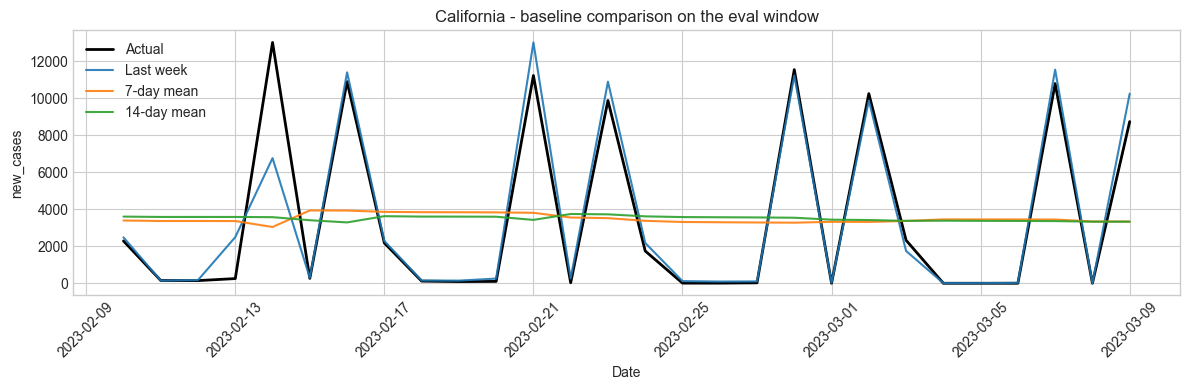

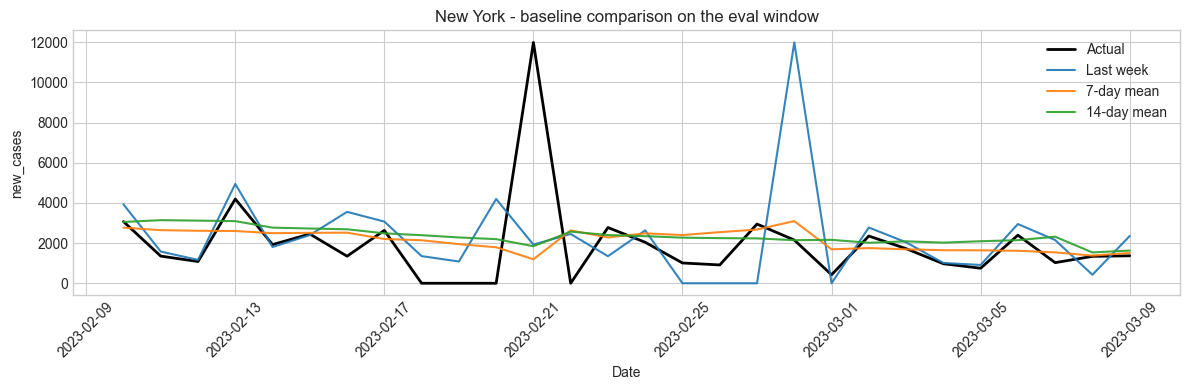

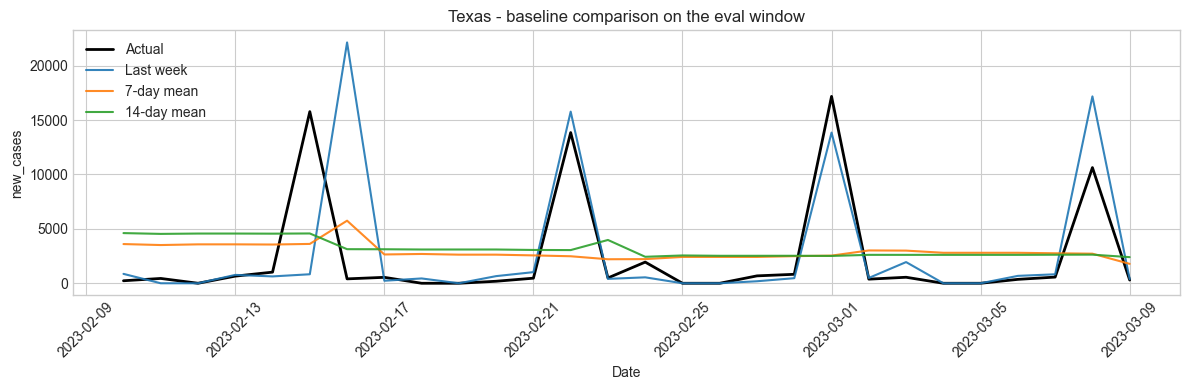

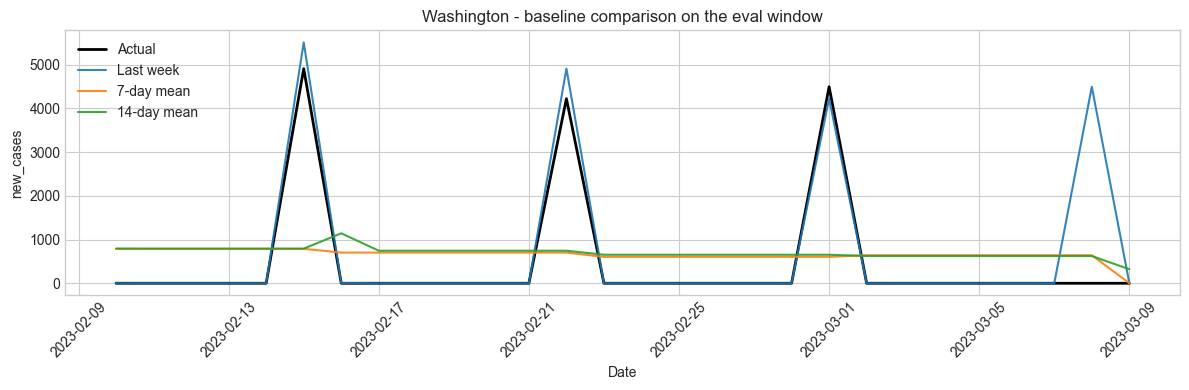

In [8]:
SAMPLE_STATES = ["California", "New York", "Texas", "Washington"]
BASELINE_PLOT_SPECS = [
    ("Last week", "baseline_last_week"),
    ("7-day mean", "baseline_roll_mean_7"),
    ("14-day mean", "baseline_roll_mean_14"),
]

if baseline_eval.empty:
    print("No baseline plots yet. Load the data first.")
else:
    available_states = set(baseline_eval["state"])
    for state_name in SAMPLE_STATES:
        if state_name in available_states:
            plot_baseline_comparison(baseline_eval, state_name, BASELINE_PLOT_SPECS)


## Sequence Dataset

The processing pipeline also builds fixed-length lookback windows for the forecast task used by the GRU benchmark.


In [9]:
if model_frame.empty:
    print("No sequence dataset yet.")
else:
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    display(meta.head())


X shape: (63510, 28, 9)
y shape: (63510,)


,state,target_date
0,Alabama,2020-03-10
1,Alabama,2020-03-11
2,Alabama,2020-03-12
3,Alabama,2020-03-13
4,Alabama,2020-03-14


## GRU Comparison

This section compares three GRU variants on the same 7-day forecast task:
- `GRU Direct`: an initial direct-target GRU
- `GRU Residual`: the tuned residual-correction GRU
- `GRU State Consistency`: a state-aware residual GRU that uses state-level target scaling, a learned state embedding, equal-state weighting, and checkpoint selection by mean per-state MAE


In [10]:
try:
    from scripts.gru_direct import run_direct_gru_benchmark
    from scripts.gru_residual import run_residual_gru_benchmark
    from scripts.gru_state_consistency import run_state_consistency_gru_benchmark
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Install the dependencies from requirements.txt before running the GRU comparison. Missing package: torch"
    ) from exc

def plot_training_history(history, title):
    if history.empty:
        print("No training history to plot.")
        return

    loss_label = "loss"
    if "loss_name" in history.columns and not history.empty:
        loss_label = str(history["loss_name"].iat[0])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["epoch"], history["train_loss"], label="Train", linewidth=2.0)
    ax.plot(history["epoch"], history["eval_loss"], label="Eval", linewidth=2.0)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"{loss_label} on transformed target")
    ax.legend()
    plt.tight_layout()

    backend_name = plt.get_backend().lower()
    if "agg" in backend_name:
        plt.close(fig)
    else:
        plt.show()

def plot_sequence_forecast_comparison(frame, state_name, prediction_specs, actual_column="actual_new_cases"):
    state_frame = frame[frame["state"] == state_name].copy()
    state_frame = state_frame.sort_values("target_date").reset_index(drop=True)

    if state_frame.empty:
        print(f"No sequence evaluation data found for {state_name}.")
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(state_frame["target_date"], state_frame[actual_column], label="Actual", linewidth=2.0, color="black")

    for label, prediction_column in prediction_specs:
        if prediction_column in state_frame.columns:
            ax.plot(state_frame["target_date"], state_frame[prediction_column], label=label, linewidth=1.5, alpha=0.9)

    ax.set_title(f"{state_name} - 7-day forecast comparison")
    ax.set_xlabel("Target date")
    ax.set_ylabel(actual_column)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    backend_name = plt.get_backend().lower()
    if "agg" in backend_name:
        plt.close(fig)
    else:
        plt.show()


Sequence train rows: 61,886
Sequence eval rows: 1,624
Lookback days: 28
Forecast horizon: 7 day(s)


GRU Direct device: cpu


GRU Residual device: cpu


GRU State Consistency device: cpu


Sequence-level benchmark for the GRU comparison:


...

Best model by state count:


,Baseline,Best State Count
0,GRU Direct,18
1,Last observed day,18
2,GRU State Consistency,11
3,GRU Residual,9
4,14-day input mean,2


Combined training history:


,model_key,display_name,epoch,loss_name,train_loss,eval_loss,checkpoint_metric_name,checkpoint_metric_value,device
0,gru_direct,GRU Direct,1,mse,0.314756,0.242582,eval_loss,0.242582,cpu
1,gru_direct,GRU Direct,2,mse,0.183928,0.237850,eval_loss,0.237850,cpu
2,gru_direct,GRU Direct,3,mse,0.179442,0.236768,eval_loss,0.236768,cpu
3,gru_direct,GRU Direct,4,mse,0.177360,0.234914,eval_loss,0.234914,cpu
4,gru_direct,GRU Direct,5,mse,0.175426,0.235465,eval_loss,0.235465,cpu
...,...,...,...,...,...,...,...,...,...
145,gru_state_consistency,GRU State Consistency,46,huber,0.140444,0.066876,mean_state_mae,386.290588,cpu
146,gru_state_consistency,GRU State Consistency,47,huber,0.139476,0.068508,mean_state_mae,416.277740,cpu
147,gru_state_consistency,GRU State Consistency,48,huber,0.138597,0.066524,mean_state_mae,349.214966,cpu
148,gru_state_consistency,GRU State Consistency,49,huber,0.139548,0.071517,mean_state_mae,384.657013,cpu


Best simple baseline: Last observed day
Best GRU variant: GRU Residual
GRU Direct beat the best simple baseline on RMSE: True
GRU Direct beat the best simple baseline on WAPE: True
GRU Direct beat the best simple baseline on Average Rank: True
GRU Residual beat the best simple baseline on RMSE: True
GRU Residual beat the best simple baseline on WAPE: True
GRU Residual beat the best simple baseline on Average Rank: True
GRU State Consistency beat the best simple baseline on RMSE: True
GRU State Consistency beat the best simple baseline on WAPE: True
GRU State Consistency beat the best simple baseline on Average Rank: True


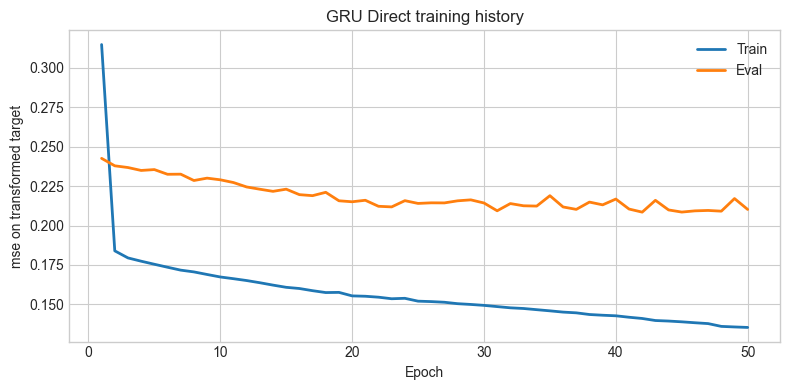

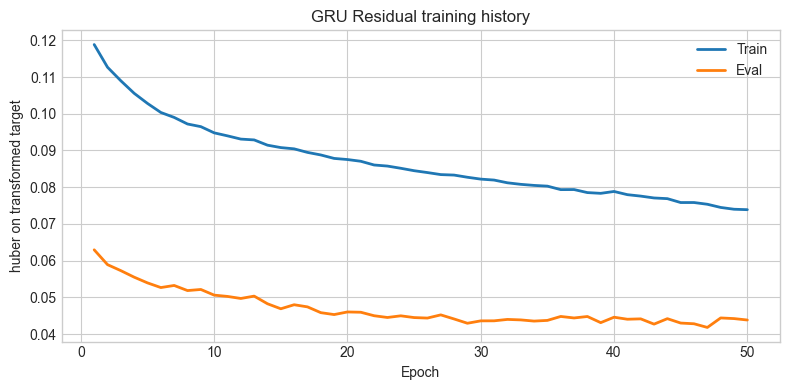

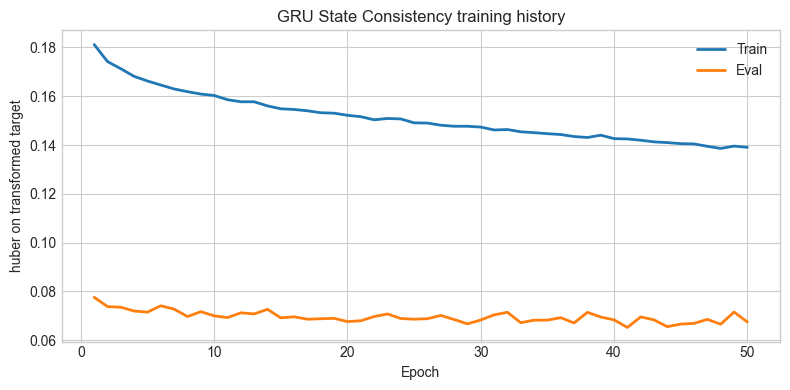

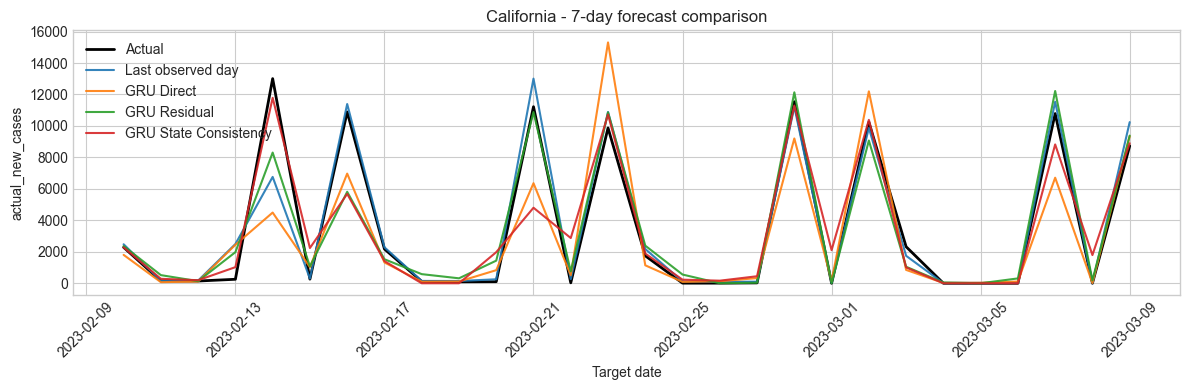

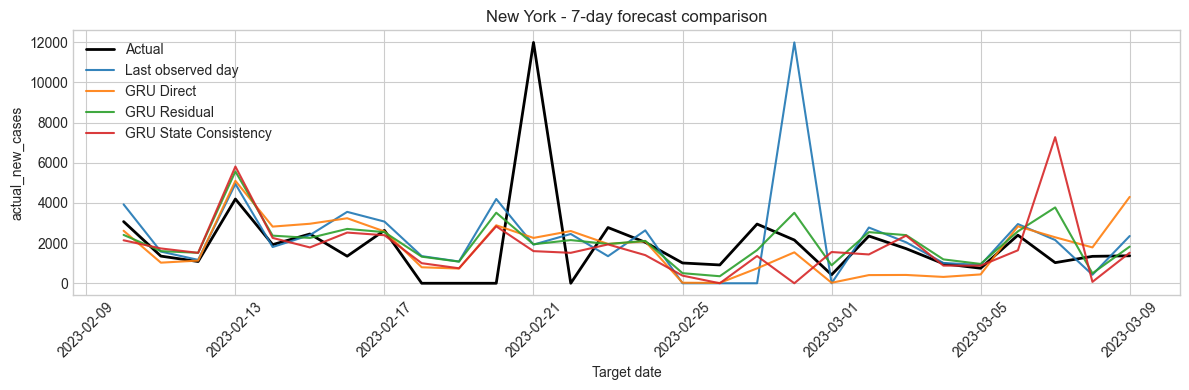

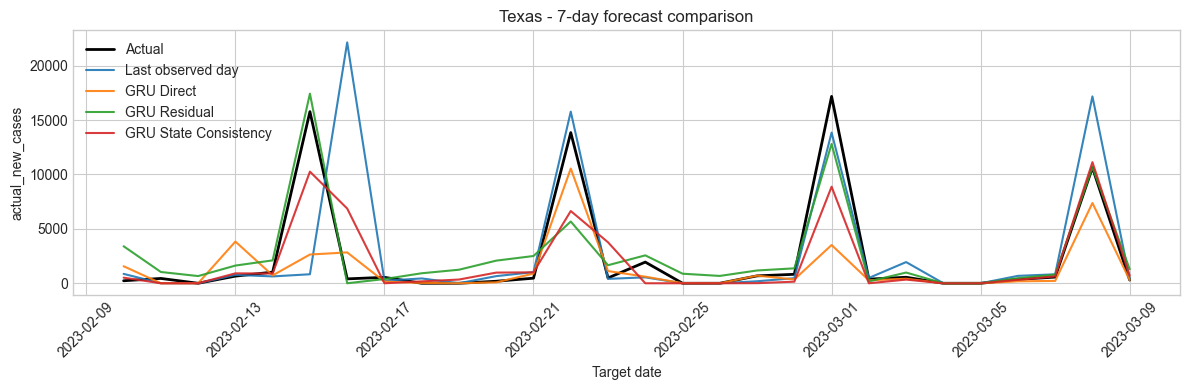

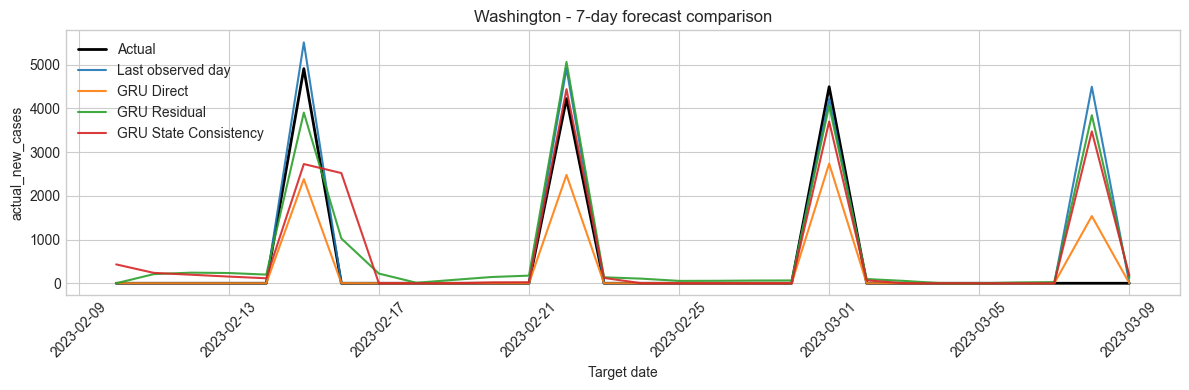

Wrote: /Users/magicalfeyfenny/GitHub/COVID-19/data/processed/sequence_eval_predictions.csv
Wrote: /Users/magicalfeyfenny/GitHub/COVID-19/data/processed/sequence_benchmark_scores.csv
Wrote: /Users/magicalfeyfenny/GitHub/COVID-19/data/processed/gru_training_history.csv


In [11]:
GRU_RANDOM_SEED = 42
GRU_RUNNERS = [
    run_direct_gru_benchmark,
    run_residual_gru_benchmark,
    run_state_consistency_gru_benchmark,
]

if model_frame.empty:
    sequence_eval_frame = pd.DataFrame()
    sequence_benchmark_scores = pd.DataFrame()
    sequence_state_scores = pd.DataFrame()
    best_sequence_model_by_state = pd.DataFrame()
    best_sequence_model_state_counts = pd.DataFrame()
    gru_history = pd.DataFrame()
    gru_results = []
    print("No GRU benchmark yet. Load the data first.")
else:
    sequence_train_X, sequence_train_y, sequence_train_meta, sequence_eval_X, sequence_eval_y, sequence_eval_meta = split_sequence_dataset_by_date(
        X, y, meta, cutoff_date
    )

    sequence_eval_frame = build_sequence_baseline_frame(
        sequence_train_y,
        sequence_train_meta,
        sequence_eval_X,
        sequence_eval_y,
        sequence_eval_meta,
        feature_columns=FEATURE_COLUMNS,
    )

    print(f"Sequence train rows: {len(sequence_train_y):,}")
    print(f"Sequence eval rows: {len(sequence_eval_y):,}")
    print(f"Lookback days: {LOOKBACK_DAYS}")
    print(f"Forecast horizon: {FORECAST_HORIZON} day(s)")

    gru_results = []
    for run_gru_model in GRU_RUNNERS:
        result = run_gru_model(
            sequence_train_X,
            sequence_train_y,
            sequence_train_meta,
            sequence_eval_X,
            sequence_eval_y,
            sequence_eval_meta,
            FEATURE_COLUMNS,
            target_column="new_cases",
            random_seed=GRU_RANDOM_SEED,
        )
        sequence_eval_frame[result["prediction_column"]] = result["predictions"]
        gru_results.append(result)
        print(f"{result['display_name']} device: {result['device']}")

    if gru_results:
        gru_history = pd.concat([result["history"] for result in gru_results], ignore_index=True)
    else:
        gru_history = pd.DataFrame()

    sequence_model_specs = SEQUENCE_BASELINE_SPECS + [
        (result["display_name"], result["prediction_column"])
        for result in gru_results
    ]
    sequence_benchmark_scores = compare_baselines(sequence_eval_frame, "actual_new_cases", sequence_model_specs)
    sequence_state_scores = compare_baselines_by_state(sequence_eval_frame, "actual_new_cases", sequence_model_specs)
    best_sequence_model_by_state, best_sequence_model_state_counts = summarize_best_baseline_by_state(sequence_state_scores)

    gru_display_names = {result["display_name"] for result in gru_results}
    baseline_rows = sequence_benchmark_scores[~sequence_benchmark_scores["Baseline"].isin(gru_display_names)].reset_index(drop=True)
    best_simple_baseline_row = baseline_rows.iloc[0]
    best_gru_row = sequence_benchmark_scores[sequence_benchmark_scores["Baseline"].isin(gru_display_names)].iloc[0]
    best_simple_baseline_name = best_simple_baseline_row["Baseline"]

    print("Sequence-level benchmark for the GRU comparison:")
    display(sequence_benchmark_scores)
    print("Best model by state count:")
    display(best_sequence_model_state_counts)
    print("Combined training history:")
    display(gru_history)

    print(f"Best simple baseline: {best_simple_baseline_name}")
    print(f"Best GRU variant: {best_gru_row['Baseline']}")

    for result in gru_results:
        model_row = sequence_benchmark_scores[sequence_benchmark_scores["Baseline"] == result["display_name"]].iloc[0]
        print(f"{result['display_name']} beat the best simple baseline on RMSE: {model_row['RMSE'] < best_simple_baseline_row['RMSE']}")
        print(f"{result['display_name']} beat the best simple baseline on WAPE: {model_row['WAPE (%)'] < best_simple_baseline_row['WAPE (%)']}")
        print(f"{result['display_name']} beat the best simple baseline on Average Rank: {model_row['Average Rank'] < best_simple_baseline_row['Average Rank']}")

    for result in gru_results:
        plot_training_history(result["history"], f"{result['display_name']} training history")

    model_column_by_name = dict(sequence_model_specs)
    sequence_plot_specs = [(best_simple_baseline_name, model_column_by_name[best_simple_baseline_name])] + [
        (result["display_name"], result["prediction_column"])
        for result in gru_results
    ]

    available_states = set(sequence_eval_frame["state"])
    for state_name in SAMPLE_STATES:
        if state_name in available_states:
            plot_sequence_forecast_comparison(sequence_eval_frame, state_name, sequence_plot_specs)

    sequence_eval_output_path = PROCESSED_DATA_DIR / "sequence_eval_predictions.csv"
    sequence_score_output_path = PROCESSED_DATA_DIR / "sequence_benchmark_scores.csv"
    history_output_path = PROCESSED_DATA_DIR / "gru_training_history.csv"

    sequence_eval_frame.to_csv(sequence_eval_output_path, index=False)
    sequence_benchmark_scores.to_csv(sequence_score_output_path, index=False)
    gru_history.to_csv(history_output_path, index=False)

    print(f"Wrote: {sequence_eval_output_path}")
    print(f"Wrote: {sequence_score_output_path}")
    print(f"Wrote: {history_output_path}")


In [12]:
if model_frame.empty:
    print("No processed feature table to save yet.")
else:
    output_path = PROCESSED_DATA_DIR / "us_state_daily_features.csv"
    model_frame.to_csv(output_path, index=False)
    print(f"Wrote: {output_path}")


Wrote: /Users/magicalfeyfenny/GitHub/COVID-19/data/processed/us_state_daily_features.csv


## Outputs

The notebook writes these files under `data/processed/`:
- `us_state_daily.csv`
- `us_state_daily_features.csv`
- `sequence_eval_predictions.csv`
- `sequence_benchmark_scores.csv`
- `gru_training_history.csv` with rows for all three GRU variants
